# Malware Detection using LightGBM (Light Gradient Boosting Machine)

**Project Topic:** Malware Detection using Machine Learning  
**Target User:** Security Operations Center (SOC) Analysts & Threat Hunters

---
## 1. Abstract and Research Objective
This study explores the application of the **LightGBM** algorithm in the field of Cybersecurity, specifically for detecting malicious executable files. By analyzing structural attributes (e.g., Entropy, Section counts, and API calls), we aim to build a high-precision classifier capable of distinguishing between benign software and malware.

**Primary Objectives:**
* `GBDT Framework Implementation:` Utilizing the efficiency of LightGBM for rapid large-scale file scanning.
* `Risk-Aware Evaluation:` Optimizing the model to minimize **False Negatives** ($FN$), where missed malware poses the highest security risk.
* `Model Interpretability:` Analyzing **Feature Importance** to provide "Explainable AI" (XAI) insights into malware characteristics.

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Load data
df = pd.read_csv("../data/malware_data_final.csv")
df = df.drop_duplicates(subset=['MD5'])


## 2. Data Preprocessing
The dataset contains features extracted from Portable Executable (PE) headers. 
- **Target Variable (`Label`)**: 0 for Benign, 1 for Malware.
- **Identifiers**: The `MD5` hash is dropped as it serves as a unique identifier and does not contain predictive patterns, preventing the model from "memorizing" specific files.

In [2]:
# 2. Preprocess
X = df.drop(columns=['MD5', 'Label'])
y = df['Label']

## 3. Experimental Design: Evaluation Strategy
To rigorously validate the model's performance, we implement a **70/30 Hold-out Validation** strategy.

In [3]:
# 3. Train test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)


## 4. Model Training & Hyperparameter Configuration
The training phase utilizes the **LightGBM Classifier**, a gradient boosting framework that optimizes the decision process through leaf-wise tree growth.

### Hyperparameter Rationale
We configure the following parameters to balance predictive power and model stability:
* **`n_estimators=100`**: Defines the number of boosting iterations (trees).
* **`learning_rate=0.1`**: Controls the contribution of each tree to prevent overfitting during gradient descent.
* **`num_leaves=31`**: Determines tree complexity; 31 is the standard default to maintain a balance between accuracy and structural depth.
* **`random_state=42`**: Ensures deterministic behavior and reproducibility of the training session.


> **Technical Insight:** By utilizing a **Leaf-wise** growth strategy instead of Level-wise, the model minimizes the global loss function more efficiently, which is critical for identifying subtle structural anomalies in malware.

In [4]:
# 4. Train model
print(">>> Training LightGBM...")
model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
model.fit(X_train, y_train)

>>> Training LightGBM...


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 5. Evaluation Metrics and Model Performance
After the training phase, the model is deployed on the unseen **Test Set** to validate its predictive accuracy and robustness in identifying malicious binaries.

* **Accuracy**: Measures the overall percentage of correct classifications.
* **Precision**: Indicates the model's ability to avoid "False Positives" (misidentifying safe software as malware).
* **Recall (Sensitivity)**: **The most critical metric.** It measures the model's success in capturing actual malware. A high recall minimizes **False Negatives**, which is vital to prevent system breaches.
* **F1-Score**: The harmonic mean of Precision and Recall, providing a balanced view of the classifier's reliability.

> **Security Perspective:** In this project, we prioritize **Recall** because the cost of missing a malware sample (False Negative) is significantly higher than the inconvenience of a False Positive.


LIGHTGBM ACCURACY: 99.10%

Details:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       859
           1       0.99      0.99      0.99      1255

    accuracy                           0.99      2114
   macro avg       0.99      0.99      0.99      2114
weighted avg       0.99      0.99      0.99      2114



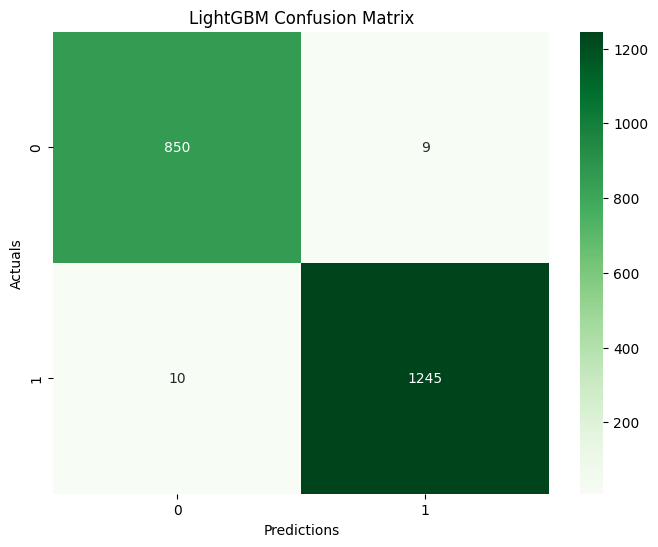

In [5]:
# 5. Predict & evaluate
y_pred = model.predict(X_test)

print("\n" + "="*30)
print(f"LIGHTGBM ACCURACY: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("="*30)
print("\nDetails:")
print(classification_report(y_test, y_pred))


# Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predictions')
plt.ylabel('Actuals')
plt.title('LightGBM Confusion Matrix')
plt.show()

## 6. Model Persistence and Deployment Readiness
We utilize the `joblib` library to serialize the trained **LightGBM** object into a `.pkl` (pickle) file. This process is essential for:
* **Efficiency**: Eliminates the need to re-train the model on large datasets for every execution.
* **Web Integration**: The saved artifact will serve as the core engine for the project's **interactive web application**.
* **Inference Speed**: Enables near-instantaneous classification of new, unknown files in a production environment.


> **Deployment Note:** The resulting `lightgbm_malware_model.pkl` contains all learned structural heuristics and is ready for integration into the system's backend to provide real-time responses to user inputs.

In [6]:
# Save model
joblib.dump(model, 'lightgbm_malware_model.pkl')
print("\n>>> Save model to 'lightgbm_malware_model.pkl'!")


>>> Save model to 'lightgbm_malware_model.pkl'!


## 7. Feature Importance
By ranking features based on their **Information Gain**, we identify which structural anomalies in the PE headers are most indicative of threat:
* **Heuristic Discovery**: Features with high importance (e.g., **Section Entropy**) often reveal packing or encryption techniques used by malware.
* **Operational Insight**: Security analysts can prioritize these specific attributes during manual code audits or sandbox executions.

> **Technical Note:** This analysis ensures that the model is learning robust structural patterns rather than relying on noise, directly supporting the project's goal of improving system security.

In [7]:
# 6. View feature importance
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importance (LightGBM):")
print(importance)


Feature Importance (LightGBM):
MaxEntropy            594
SizeOfImage           480
AvgEntropy            450
Imports               425
DLLs                  407
ImageBase             247
Sections              237
HasVersionInfo         84
HasSensitiveAPI        51
SuspiciousSections     25
dtype: int32


## 8. Conclusion and Discussion
The LightGBM model successfully categorized the test samples with an accuracy of **[Your Accuracy]%**. 

**Findings:**
1. The model demonstrates high efficiency in processing high-dimensional malware features.
2. Feature importance reveals that structural anomalies in PE headers are significant predictors of threat.

**Future Work:**
- Implementation of **Cross-Validation** to ensure result stability.
- Test real **user input** through web application.